In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look clean
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Show all columns when printing dataframes
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
df = pd.read_csv('../data/raw/telco-churn.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Coulumns: {df.shape[1]}")
print("\n--- First 5 rows ---")
df.head

Dataset Shape: (7043, 21)
Rows: 7,043 | Coulumns: 21

--- First 5 rows ---


<bound method NDFrame.head of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  \
0              No  No phone service             DSL        

In [3]:
# Data quality check
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

print(f"\nTotal missing values: {df.isnull().sum().sum()}")

=== DATA TYPES ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== MISSING VALUES ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total missing values: 0


In [4]:
# Fixing TotalCharges(it should be numeric but got string object)
print("TotalCharges sample values with spaces:")
# there are blank spaces at TotalCharges thay why it showing object(sting) rather than neumeric value
print(df[df['TotalCharges'] == ' '][['customerID', 'tenure', 'TotalCharges']].head(15))
print(f"Count of problematic rows: {(df['TotalCharges'] == ' ').sum()}")

TotalCharges sample values with spaces:
      customerID  tenure TotalCharges
488   4472-LVYGI       0             
753   3115-CZMZD       0             
936   5709-LVOEQ       0             
1082  4367-NUYAO       0             
1340  1371-DWPAZ       0             
3331  7644-OMVMY       0             
3826  3213-VVOLG       0             
4380  2520-SGTTA       0             
5218  2923-ARZLG       0             
6670  4075-WKNIU       0             
6754  2775-SEFEE       0             
Count of problematic rows: 11


In [5]:
# These are new customers (tenure = 0) — thats why TotalCharges is blank
# Fix: convert to numeric, spaces become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

# Fill NaN with 0 (logical — new customer, 0 charges so far)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("\nTotalCharges dtype after fix:", df['TotalCharges'].dtype)
print("Missing values after fix:", df['TotalCharges'].isnull().sum())


TotalCharges dtype after fix: float64
Missing values after fix: 0


In [6]:
# Diagnosing "churn" column
print(f"total rows in churn column {len(df['Churn'])}")
print(f"NaN count in Churn: {df['Churn'].isnull().sum()}")

total rows in churn column 7043
NaN count in Churn: 0


=== CHURN DISTRIBUTION ===
Not Churned (0): 5,174  (73.5%)
Churned     (1): 1,869  (26.5%)


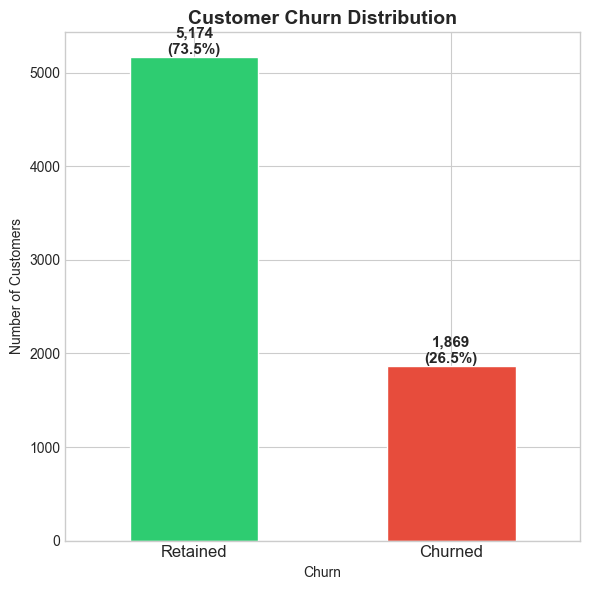

In [7]:
# Understand what we're predicting

# Convert target to binary (Yes/No → 1/0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("=== CHURN DISTRIBUTION ===")
print(f"Not Churned (0): {churn_counts[0]:,}  ({churn_pct[0]:.1f}%)")
print(f"Churned     (1): {churn_counts[1]:,}  ({churn_pct[1]:.1f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(6, 6))
colors = ['#2ecc71', '#e74c3c']
churn_counts.plot(kind='bar', color=colors, ax=ax, edgecolor='white')
ax.set_xticklabels(['Retained', 'Churned'], rotation=0, fontsize=12)
ax.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Customers')

for i, v in enumerate(churn_counts):
    ax.text(i, v + 30, f'{v:,}\n({churn_pct[i]:.1f}%)', 
            ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

📌 Document this as Business Insight #1: "The dataset has a 26.5% churn rate — significantly higher than industry averages of 10–15%, making this a high-priority retention problem. Class imbalance means accuracy is a misleading metric; we optimize for Recall and ROC-AUC instead."

['Month-to-month' 'One year' 'Two year']
Index(['Contract', 'mean', 'count'], dtype='object')
    Contract Type  Customer Count  Churn Rate (%)
0  Month-to-month            3875           42.71
1        One year            1473           11.27
2        Two year            1695            2.83


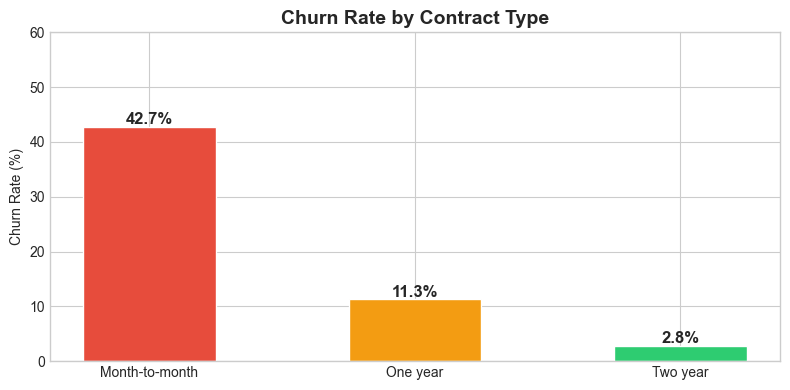

In [8]:
# Churn by Contract Type — Business Insight #2

print(df['Contract'].unique())
contract_churn = df.groupby('Contract')['Churn'].agg(['mean', 'count']).reset_index()
print(contract_churn.columns)
contract_churn['churn_rate'] = contract_churn['mean'] * 100
contract_churn.columns = ['Contract Type', 'Churn Rate (Raw)', 'Customer Count', 'Churn Rate (%)']

print(contract_churn[['Contract Type', 'Customer Count', 'Churn Rate (%)']])

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = ax.bar(contract_churn['Contract Type'], 
              contract_churn['Churn Rate (%)'], 
              color=colors, edgecolor='white', width=0.5)

ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 60)

for bar, val in zip(bars, contract_churn['Churn Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

📌 Business Insight #2: "Month-to-month customers churn at ~42% vs ~11% for 1-year and ~3% for 2-year contracts. This is the single most actionable finding — the business should prioritize converting month-to-month customers to annual contracts as a retention strategy."

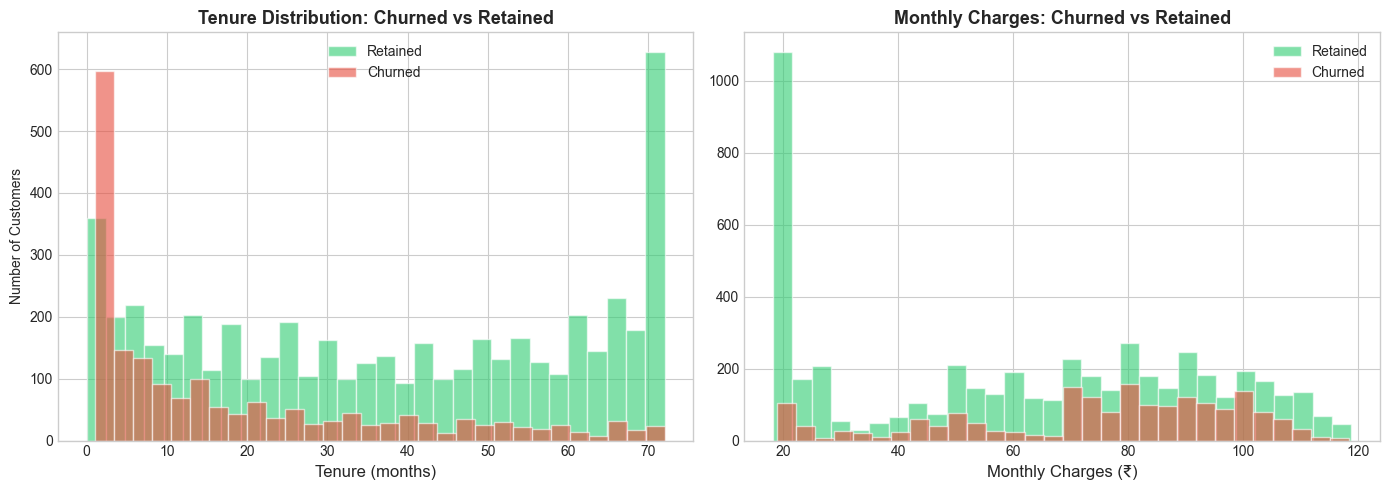

Avg tenure  — Churned: 18.0 months  | Retained: 37.6 months
Avg charges — Churned: ₹74.44/mo | Retained: ₹61.27/mo


In [9]:
# Churn by Tenure — Business Insight #3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Tenure distribution by churn
churned = df[df['Churn'] == 1]['tenure']
retained = df[df['Churn'] == 0]['tenure']

axes[0].hist(retained, bins=30, alpha=0.6, color='#2ecc71', label='Retained', edgecolor='white')
axes[0].hist(churned, bins=30, alpha=0.6, color='#e74c3c', label='Churned', edgecolor='white')
axes[0].set_xlabel('Tenure (months)', fontsize=12)
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Tenure Distribution: Churned vs Retained', fontsize=13, fontweight='bold')
axes[0].legend()

# Right: Monthly Charges distribution
churned_charges = df[df['Churn'] == 1]['MonthlyCharges']
retained_charges = df[df['Churn'] == 0]['MonthlyCharges']

axes[1].hist(retained_charges, bins=30, alpha=0.6, color='#2ecc71', label='Retained', edgecolor='white')
axes[1].hist(churned_charges, bins=30, alpha=0.6, color='#e74c3c', label='Churned', edgecolor='white')
axes[1].set_xlabel('Monthly Charges (₹)', fontsize=12)
axes[1].set_title('Monthly Charges: Churned vs Retained', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/tenure_charges_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Avg tenure  — Churned: {churned.mean():.1f} months  | Retained: {retained.mean():.1f} months")
print(f"Avg charges — Churned: ₹{churned_charges.mean():.2f}/mo | Retained: ₹{retained_charges.mean():.2f}/mo")

📌 Business Insight #3: "Churned customers have significantly lower average tenure (18 months vs 37 months) and higher monthly charges (₹74 vs ₹61). Early-stage, high-paying customers are the highest churn risk — these should be the primary target for retention campaigns."

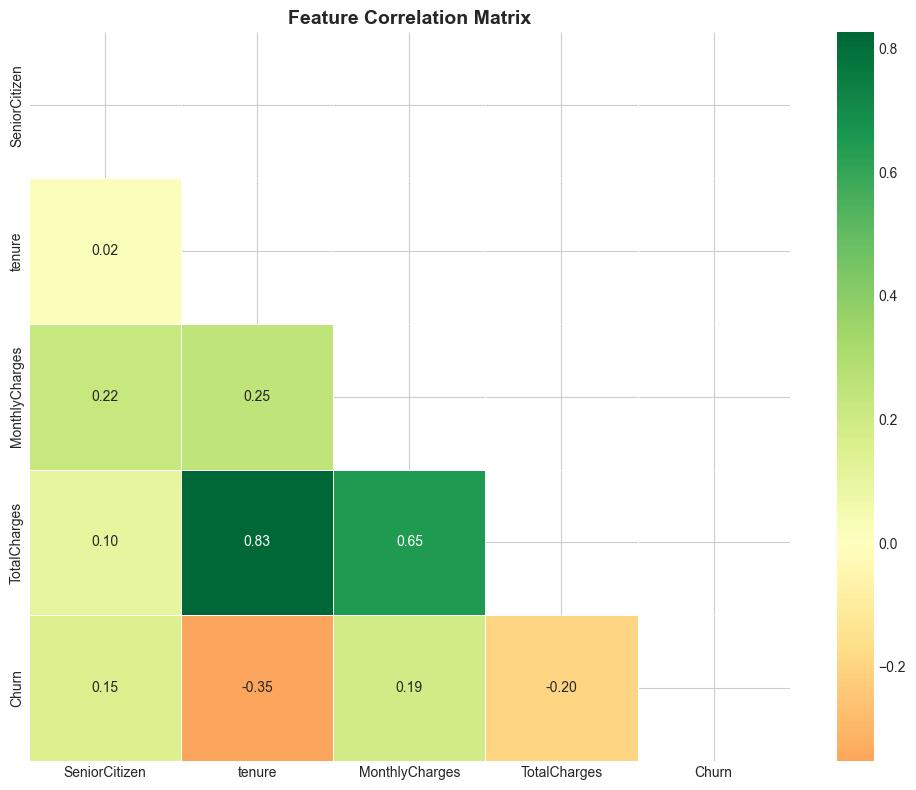

=== TOP CORRELATIONS WITH CHURN ===
tenure           -0.35
TotalCharges     -0.20
MonthlyCharges    0.19
SeniorCitizen     0.15
Name: Churn, dtype: float64


In [10]:
# Correlation heatmap — shows which features relate to churn

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Hide upper triangle (redundant)

sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            center=0,
            ax=ax,
            linewidths=0.5)

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with Churn specifically
print("=== TOP CORRELATIONS WITH CHURN ===")
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print(churn_corr.head(10))

In [11]:
# Save the cleaned dataset for use in Day 2

# Drop customerID — it's just an identifier, not a feature
df_clean = df.drop('customerID', axis=1)

# Save
df_clean.to_csv('../data/processed/telco_churn_cleaned.csv', index=False)

print(f"Cleaned dataset saved ✅")
print(f"Shape: {df_clean.shape}")
print(f"Columns: {list(df_clean.columns)}")

Cleaned dataset saved ✅
Shape: (7043, 20)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
